<a href="https://colab.research.google.com/github/norman-AI-2025/athlete-performance-predictor/blob/main/data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/athlete-performance-predictor/athlete-performance-predictor/2016_nba_draft_combine.csv')

In [4]:
df_clean = df.dropna(subset=['Vertical (Max)'])
columns_to_drop = [
    'index',
    'Unnamed: 0',
    'Player',
    'Year',
    'Draft pick',
    'Bench',
    'Vertical (Max Reach)',
    'Vertical (No Step)',
    'Vertical (No Step Reach)'
]
df_clean = df_clean.drop(columns=columns_to_drop)
sprint_mean = df_clean['Sprint'].mean()
df_clean['Sprint']=df_clean['Sprint'].fillna(sprint_mean)
print(df_clean.info())


<class 'pandas.core.frame.DataFrame'>
Index: 49 entries, 0 to 60
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Height (No Shoes)    49 non-null     float64
 1   Height (With Shoes)  49 non-null     float64
 2   Wingspan             49 non-null     float64
 3   Standing reach       49 non-null     float64
 4   Vertical (Max)       49 non-null     float64
 5   Weight               49 non-null     float64
 6   Body Fat             49 non-null     float64
 7   Hand (Length)        49 non-null     float64
 8   Hand (Width)         49 non-null     float64
 9   Agility              49 non-null     float64
 10  Sprint               49 non-null     float64
dtypes: float64(11)
memory usage: 4.6 KB
None


In [5]:
df_clean.head()


,Height (No Shoes),Height (With Shoes),Wingspan,Standing reach,Vertical (Max),Weight,Body Fat,Hand (Length),Hand (Width),Agility,Sprint
0,74.00,75.00,82.0,98.5,35.5,182.0,5.3,8.75,8.50,12.27,3.280000
1,79.25,80.25,85.5,105.0,33.0,229.0,9.7,9.50,10.00,11.16,3.300000
2,81.00,82.50,84.5,106.5,38.0,209.0,7.5,9.00,8.25,11.88,3.200000
4,79.50,80.50,87.5,107.0,29.0,247.0,12.6,9.00,10.25,12.80,3.308958
7,79.50,81.00,88.5,107.5,35.0,219.0,5.6,8.50,9.75,11.24,3.260000


EXPLORATORY DATA ANALYSIS

In [6]:
print("--- Target Variable Summary ---")
print(df_clean['Vertical (Max)'].describe())

--- Target Variable Summary ---
count    49.000000
mean     35.704082
std       3.773425
min      28.000000
25%      33.500000
50%      35.500000
75%      38.000000
max      44.000000
Name: Vertical (Max), dtype: float64


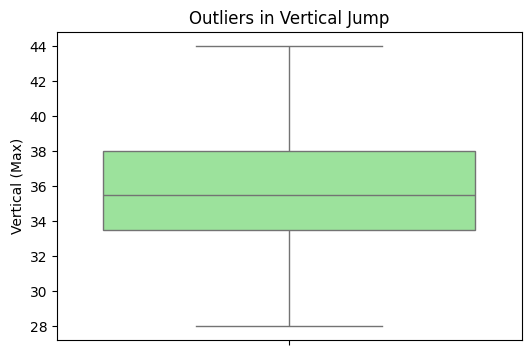

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_clean['Vertical (Max)'], color='lightgreen')
plt.title('Outliers in Vertical Jump')
plt.show()

BIVARIATE (EDA) - feature vs target

In [8]:
print("\n--- Correlations with Vertical (Max) ---")
print(df_clean.corr()['Vertical (Max)'].sort_values(ascending=False))


--- Correlations with Vertical (Max) ---
Vertical (Max)         1.000000
Hand (Width)          -0.101655
Height (No Shoes)     -0.434272
Height (With Shoes)   -0.436380
Hand (Length)         -0.471628
Wingspan              -0.522265
Weight                -0.536937
Agility               -0.549195
Standing reach        -0.571550
Body Fat              -0.622595
Sprint                -0.665462
Name: Vertical (Max), dtype: float64


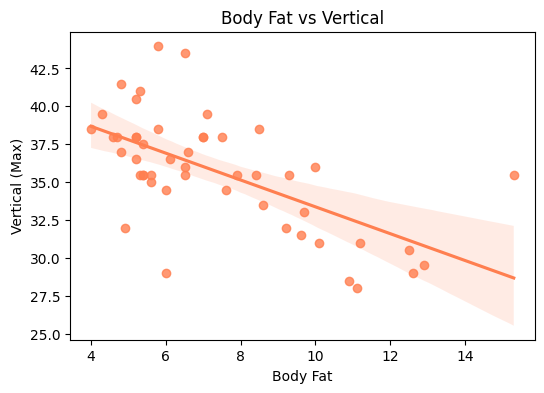

In [9]:
plt.figure(figsize=(6, 4))
sns.regplot(x='Body Fat', y='Vertical (Max)', data=df_clean, color='coral')
plt.title('Body Fat vs Vertical')
plt.show()

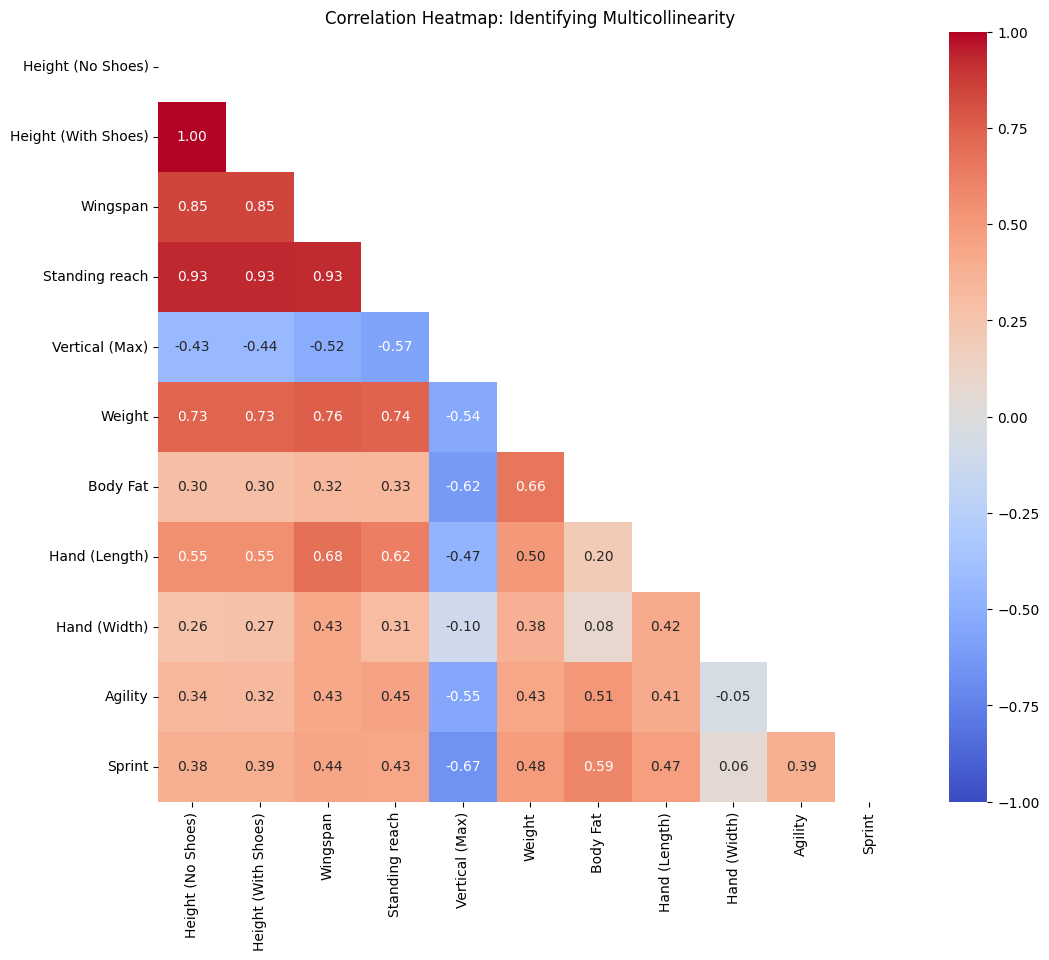

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate the correlation matrix for all numeric columns
corr_matrix = df_clean.corr()

# 2. Plot the heatmap
plt.figure(figsize=(12, 10))
# Using a mask to hide the upper triangle for better readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Identifying Multicollinearity')
plt.show()

In [11]:
# Features to drop due to multicollinearity or weak target correlation
redundant_cols = [
    'Height (With Shoes)', # Redundant with Height (No Shoes)
    'Standing reach',      # Redundant with Height + Wingspan
    'Hand (Width)'         # Weak correlation to target (-0.10)
]

# Create a new dataframe for modeling
df_model = df_clean.drop(columns=redundant_cols)

print(f"Original shape: {df_clean.shape}")
print(f"New shape (removed {len(redundant_cols)} redundant features): {df_model.shape}")

Original shape: (49, 11)
New shape (removed 3 redundant features): (49, 8)


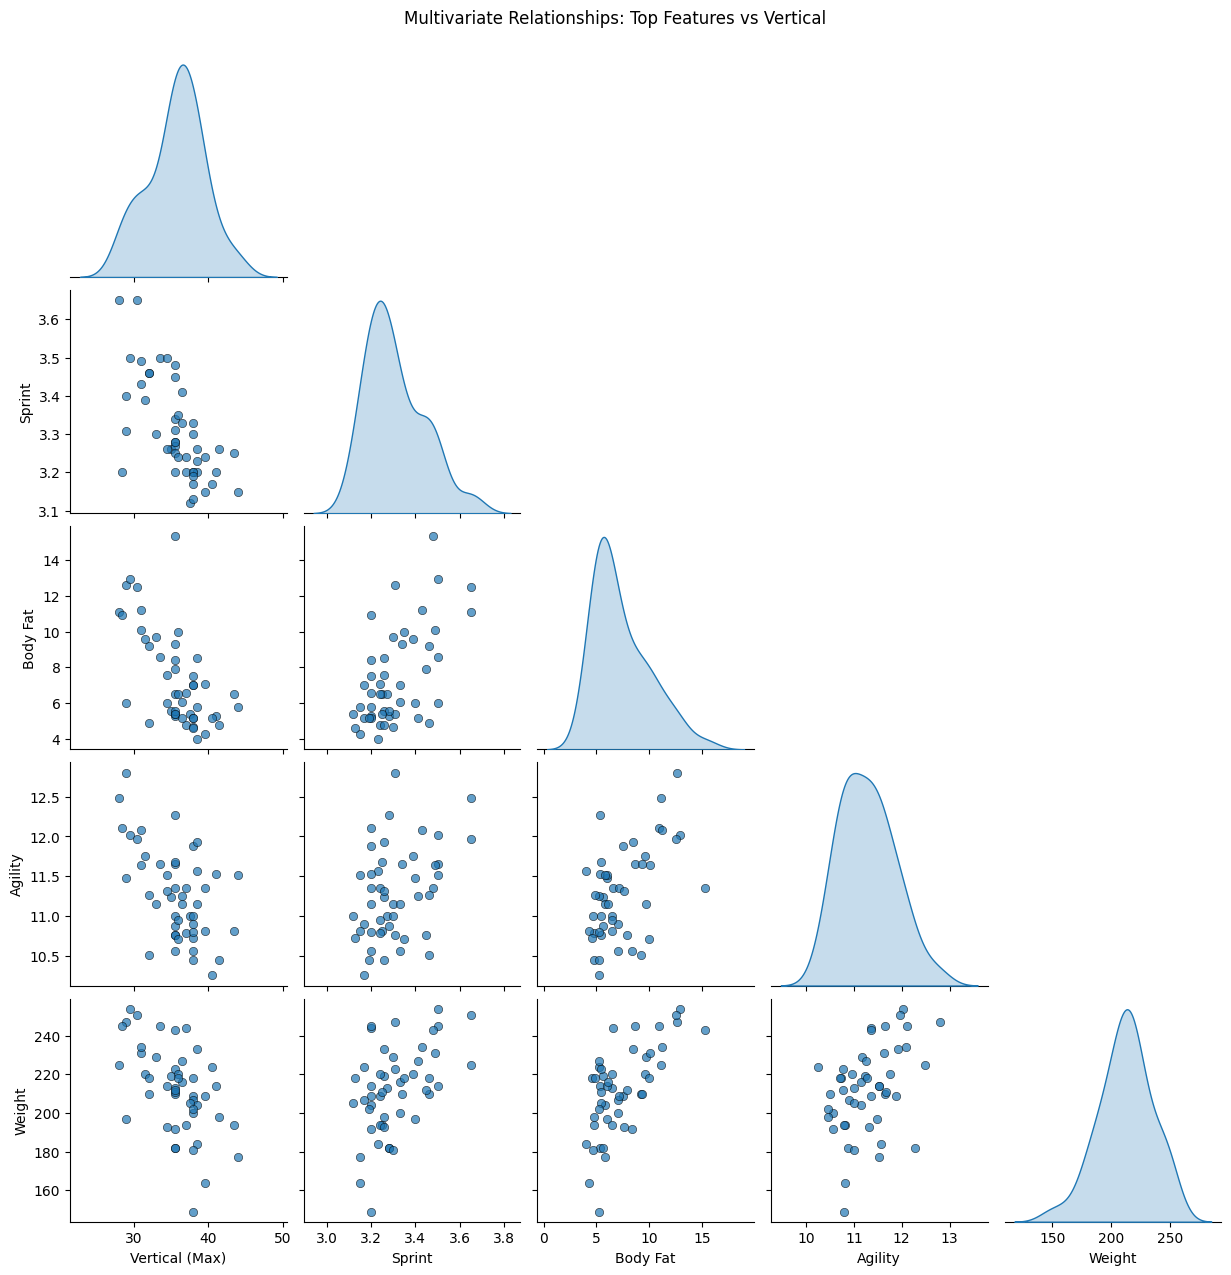

In [12]:
# Select the strongest remaining features based on your previous bivariate analysis
top_features = ['Vertical (Max)', 'Sprint', 'Body Fat', 'Agility', 'Weight']

# Plot a pairplot to see distributions and joint relationships
sns.pairplot(df_model[top_features], diag_kind='kde', corner=True,
             plot_kws={'alpha': 0.7, 'edgecolor': 'k'})
plt.suptitle('Multivariate Relationships: Top Features vs Vertical', y=1.02)
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

x=df_model.drop('Vertical (Max)',axis=1)
y=df_model['Vertical (Max)']

X_train , X_test , y_train , y_test = train_test_split(x,y,test_size = 0.2,random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (39, 7)
Testing data shape: (10, 7)


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
#training
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

#prediction
y_pred_mlr = mlr_model.predict(X_test)
r2 = r2_score(y_test,y_pred_mlr)
rmse = np.sqrt(mean_squared_error(y_test,y_pred_mlr))

print(f'Multiple Linear Regression R-squared: {r2:.3f}')
print(f"Multiple Linear Regression RMSE: {rmse:.3f} inches")



Multiple Linear Regression R-squared: -0.125
Multiple Linear Regression RMSE: 3.319 inches


In [23]:
import pandas as pd

# Create a dataframe to view the feature coefficients
coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': mlr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

             Feature  Coefficient
2             Weight     0.054771
4      Hand (Length)    -0.045204
0  Height (No Shoes)    -0.090893
1           Wingspan    -0.277963
5            Agility    -0.644447
3           Body Fat    -0.866035
6             Sprint    -8.109383


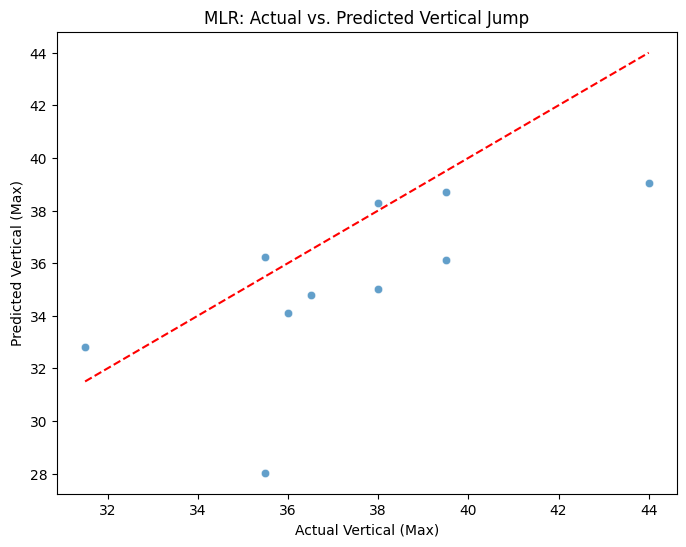

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_mlr, alpha=0.7)

# Draw the perfect prediction diagonal line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.xlabel('Actual Vertical (Max)')
plt.ylabel('Predicted Vertical (Max)')
plt.title('MLR: Actual vs. Predicted Vertical Jump')
plt.show()

implementing random forest regressor

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42,n_estimators=100)
rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test,y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))
print(f"Random Forest R-squared: {r2_rf:.3f}")
print(f"Random Forest RMSE: {rmse_rf:.3f} inches")

Random Forest R-squared: 0.265
Random Forest RMSE: 2.682 inches


--- How much each trait influenced the predictions ---
             Feature  Importance
3           Body Fat    0.476062
6             Sprint    0.257911
5            Agility    0.095397
1           Wingspan    0.061388
0  Height (No Shoes)    0.057059
2             Weight    0.033132
4      Hand (Length)    0.019050


/tmp/ipykernel_1563/3672190677.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importances, palette='mako')


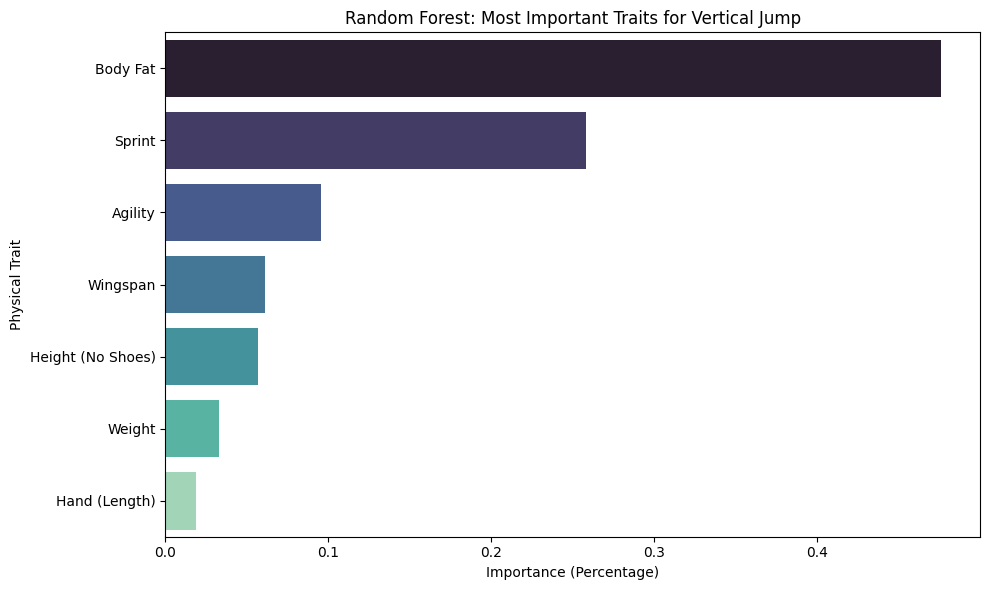

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the feature importances from the trained model
rf_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- How much each trait influenced the predictions ---")
print(rf_importances)

# Plot the importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importances, palette='mako')
plt.title('Random Forest: Most Important Traits for Vertical Jump')
plt.xlabel('Importance (Percentage)')
plt.ylabel('Physical Trait')
plt.tight_layout()
plt.show()